# 04 · Anomaly screening (beyond speech / breathing)

Sweep every recording for epileptiform-like transients, focal rhythmic delta, line noise and
interhemispheric alpha asymmetry.

In [1]:
import warnings, pathlib, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# Make the committed `analysis` package importable whether this notebook is
# launched from the repo root or from the notebooks/ folder.
_c = pathlib.Path.cwd()
REPO = next(p for p in [_c] + list(_c.parents) if (p / "analysis").is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis import dataset, eegkit as K

# Point DATA_DIR at any folder of EDFs named <subject><E|C><id>[_pN].edf
#   None -> repo data/  |  a path -> that folder  |  or set env EEG_DATA_DIR
DATA_DIR = None
recs = dataset.discover(DATA_DIR)

# Neutral per-recording labels (exp1, exp2, ctrl1, ctrl2) so participant codes
# never leak into figure titles / filenames.
_gi, LABEL = {}, {}
for _r in recs:
    _g = _r["group"]; _gi[_g] = _gi.get(_g, 0) + 1
    LABEL[_r["key"]] = ("exp" if _g == "E" else "ctrl") + str(_gi[_g])
def lbl(r): return LABEL[r["key"]]

FIG = REPO / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
IAF_DEF = 9.7

def ec_window(r):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0].startswith("rest_close")][0]

def get_iaf(r):
    raw = K.load(r["path"]); ec = ec_window(r)
    _, live = K.get(raw, ec[1], ec[2])
    return K.iaf(raw, live, ec[1], ec[2])

def stage_of(r, nm):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0] == nm]

print(f"discovered {len(recs)} recordings ->", {lbl(r): r["group"] for r in recs})
print("figures ->", str(FIG))


discovered 4 recordings -> {'exp1': 'E', 'exp2': 'E', 'ctrl1': 'C', 'ctrl2': 'C'}
figures -> /home/eugen/coding/ms-thesis/eeg-analysis/reports/figures


## 1. Spike / sharp-wave candidates

exp1: 7452 candidates (214.8/min) — blink/muscle, NOT epileptiform.


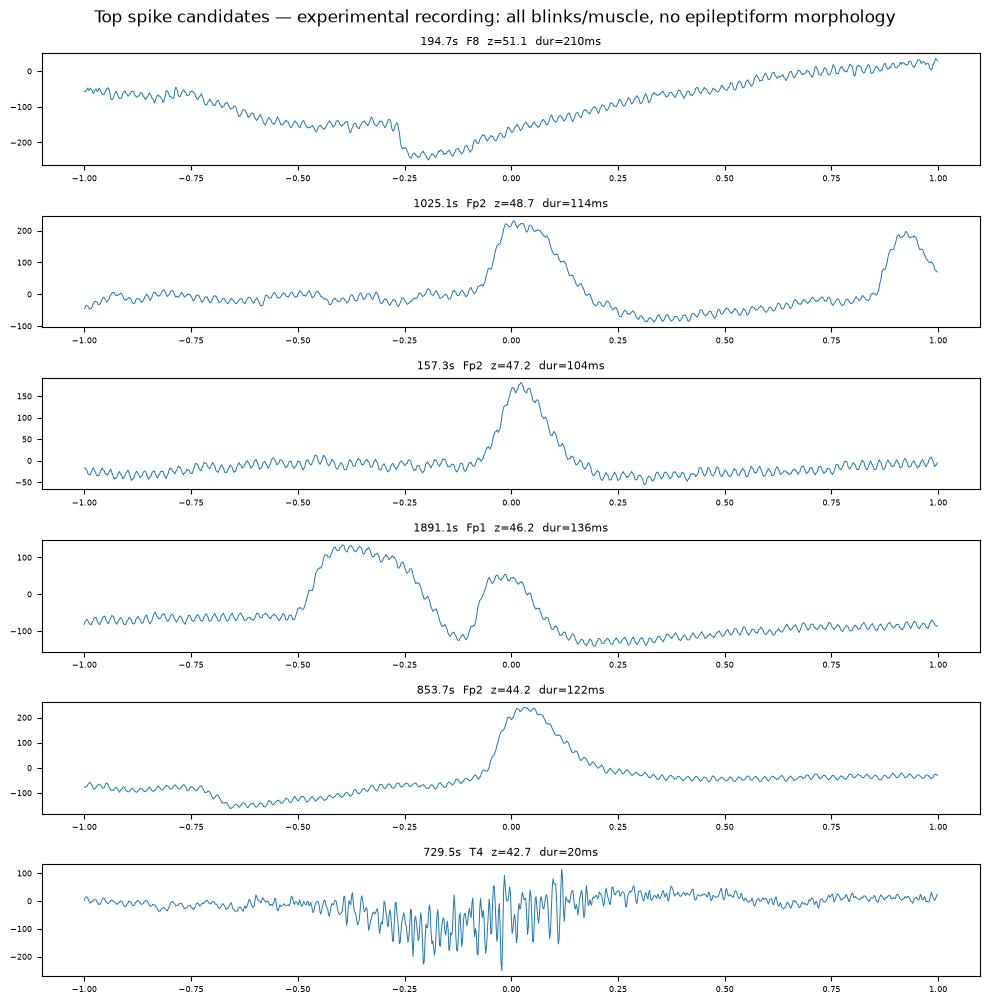

In [2]:
from scipy.signal import find_peaks
def spikes(r):
    raw = K.load(r["path"]); fs = raw.info["sfreq"]
    t_end = K.trim_time(raw) or raw.n_times / fs
    x, live = K.get(raw, 0, t_end)
    xs = K.bp(x, fs, 1, 30)
    med = np.median(xs, axis=0); mad = 1.4826 * np.median(np.abs(xs - med), axis=0) + 1e-9
    z = (xs - med) / mad; zmax = z.max(axis=0)
    pk, _ = find_peaks(zmax, height=6.0, distance=int(0.05 * fs))
    ev = []
    for p in pk:
        a = p
        while a > 0 and zmax[a - 1] > 3: a -= 1
        b = p
        while b < len(zmax) - 1 and zmax[b + 1] > 3: b += 1
        dur = (b - a) / fs * 1000
        if 20 <= dur <= 250:
            ev.append((p / fs, live[int(np.argmax(z[:, p]))], zmax[p], dur))
    return x, live, fs, ev
r = recs[0]
x, live, fs, ev = spikes(r)
print(f"{lbl(r)}: {len(ev)} candidates ({len(ev)/(x.shape[1]/fs)*60:.1f}/min) — blink/muscle, NOT epileptiform.")
top = sorted(ev, key=lambda e: -e[2])[:6]
fig, axes = plt.subplots(len(top), 1, figsize=(10, 1.7 * len(top)))
for ax, (t, ch, zv, dur) in zip(np.atleast_1d(axes), top):
    i = int(t * fs); c = live.index(ch); lo = max(0, int(i - fs)); hi = int(i + fs)
    seg = x[c, lo:hi]
    ax.plot(np.arange(-int(fs), len(seg) - int(fs)) / fs, seg, lw=0.7)
    ax.set_title(f"{t:.1f}s  {ch}  z={zv:.1f}  dur={dur:.0f}ms", fontsize=8)
    ax.tick_params(labelsize=6)
fig.suptitle("Top spike candidates — experimental recording: all blinks/muscle, no epileptiform morphology")
fig.tight_layout(); fig.savefig(FIG / "spike_candidates.png", dpi=90); plt.show(); plt.close(fig)


## 2. Focal rhythmic delta, line noise & posterior alpha asymmetry

In [3]:
def screen(r):
    raw = K.load(r["path"]); fs = raw.info["sfreq"]
    t_end = K.trim_time(raw) or raw.n_times / fs
    x, live = K.get(raw, 0, t_end)
    dlt = K.bp(x, fs, 0.5, 3.5)
    W = int(3 * fs); n_epi = 0
    for ci in range(len(live)):
        env = np.abs(dlt[ci]); m = env[:len(env) // W * W].reshape(-1, W).mean(1)
        n_epi += int(np.sum(m > 75))
    from scipy.signal import welch
    xw, lw = K.get(raw, 60, min(240, t_end))
    f, p = welch(xw.mean(0), fs=fs, nperseg=8 * fs)
    bpw = lambda lo, hi: np.trapezoid(p[(f >= lo) & (f <= hi)], f[(f >= lo) & (f <= hi)])
    line = bpw(49, 51) / (bpw(44, 46) + bpw(54, 56) + 1e-12)
    ec = ec_window(r); IAF = get_iaf(r)
    xe, le = K.get(raw, ec[1], ec[2])
    def asy(a, b):
        if a in le and b in le:
            pa = K.band_pow(xe[[le.index(a)]], fs, IAF - 2, IAF + 2).mean()
            pb = K.band_pow(xe[[le.index(b)]], fs, IAF - 2, IAF + 2).mean()
            return 100 * (pa - pb) / (pa + pb + 1e-12)
        return np.nan
    return dict(recording=lbl(r), group=r["group"], delta_episodes=n_epi,
                line_noise_index=round(line, 2),
                P3_minus_P4=round(asy("P3", "P4")), O1_minus_O2=round(asy("O1", "O2")))
print(pd.DataFrame([screen(r) for r in recs]).to_string(index=False))
print("\nNo epileptiform events, no focal delta, no 50 Hz noise.  The right-dominant posterior alpha in")
print("the stuttering subject (negative P3-P4/O1-O2) repeats on both days -> check electrode contacts.")


recording group  delta_episodes  line_noise_index  P3_minus_P4  O1_minus_O2
     exp1     E              17               0.0          -56          -23
     exp2     E               2               0.0          -68          -31
    ctrl1     C              11               0.0            4          -12
    ctrl2     C               0               0.0            0          -15

No epileptiform events, no focal delta, no 50 Hz noise.  The right-dominant posterior alpha in
the stuttering subject (negative P3-P4/O1-O2) repeats on both days -> check electrode contacts.


## 3. Crash tail (auto-detected, not hard-coded)

In [4]:
for r in recs:
    raw = K.load(r["path"]); tr = K.trim_time(raw)
    dur = raw.n_times / raw.info["sfreq"]
    print(f"  {lbl(r)}: {dur:.0f} s; crash-tail trim at {tr if tr else 'none'}")


  exp1: 2082 s; crash-tail trim at none


  exp2: 1905 s; crash-tail trim at none


  ctrl1: 1405 s; crash-tail trim at 1394.0


  ctrl2: 782 s; crash-tail trim at none
